In [57]:
import bisect
import time
import matplotlib.pyplot as plt
import numpy as np
import random
import scipy.stats as sts

In [58]:
def compute_last_compatible(intervals):
    end_times = [interval[1] for interval in intervals]
    p = [-1] * len(intervals)
    for i in range(len(intervals)):
        idx = bisect.bisect_right(end_times, intervals[i][0]) - 1
        p[i] = idx
    return p

def weighted_interval_scheduling(intervals):
    intervals = sorted(intervals, key=lambda x: x[1])
    p = compute_last_compatible(intervals)
    n = len(intervals)
    dp = [0] * n
    for i in range(n):
        include = intervals[i][2] + (dp[p[i]] if p[i] != -1 else 0)
        exclude = dp[i-1] if i > 0 else 0
        dp[i] = max(include, exclude)
    
    selected = []
    i = n - 1
    while i >= 0:
        include = intervals[i][2] + (dp[p[i]] if p[i] != -1 else 0)
        exclude = dp[i-1] if i > 0 else 0
        if include >= exclude:
            selected.append(intervals[i])
            i = p[i]
        else:
            i -= 1
    selected.reverse()
    return dp[-1], selected

In [59]:
def generate_random_intervals(n, start_range=0, end_range=1000000, min_len=1, max_len=500, min_weight=1, max_weight=100):
    intervals = []
    for _ in range(n):
        start = random.randint(start_range, end_range - min_len)
        length = random.randint(min_len, max_len)
        end = start + length
        weight = random.randint(min_weight, max_weight)
        intervals.append((start, end, weight))
    return intervals

In [60]:
def measure_algorithm_time(algorithm, input_generator, n, n_trials=5, to_ms=False):
    trial_times = []
    for _ in range(n_trials):
        data = input_generator(n)
        start = time.perf_counter()
        algorithm(data)
        end = time.perf_counter()
        elapsed = (end - start) * 1000 if to_ms else (end - start)
        trial_times.append(elapsed)
    trial_times = np.array(trial_times)
    return trial_times, trial_times.mean(), trial_times.std()

In [61]:
sizes = [i for i in range(50_000, 2_250_000, 250_000)]
n_trials = 5
n_hist = 2_000_000
n_trials_hist = 20

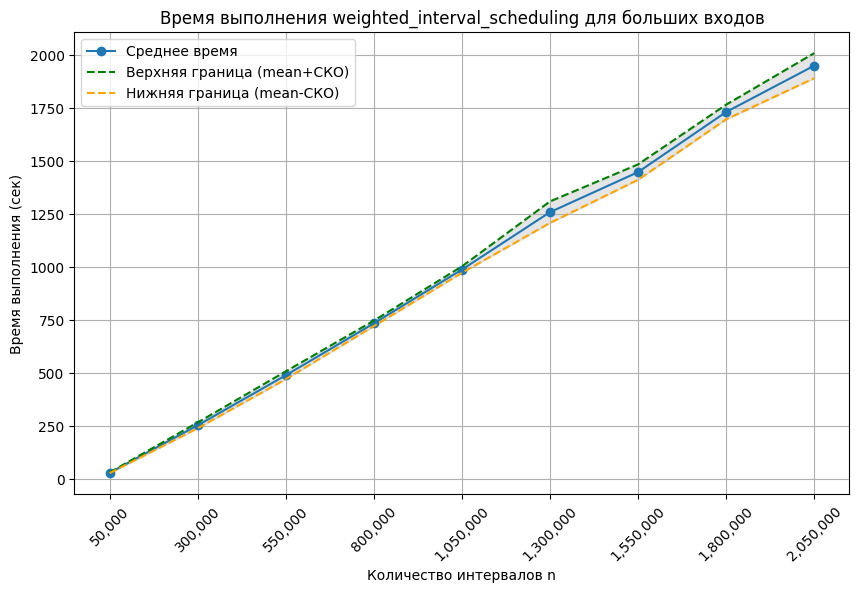

In [62]:
mean_times = []
std_times = []
q25_times = []
q75_times = []

for n in sizes:
    times, mean_t, std_t = measure_algorithm_time(weighted_interval_scheduling, generate_random_intervals, n, n_trials=n_trials)
    mean_times.append(mean_t)
    std_times.append(std_t)
    q25_times.append(np.percentile(times, 25))
    q75_times.append(np.percentile(times, 75))


mean_times = np.array(mean_times) * 1000
std_times = np.array(std_times) * 1000
upper = mean_times + std_times
lower = mean_times - std_times

plt.figure(figsize=(10,6))
plt.plot(sizes, mean_times, 'o-', label='Среднее время')
plt.plot(sizes, upper, '--', color='green', label='Верхняя граница (mean+СКО)')
plt.plot(sizes, lower, '--', color='orange', label='Нижняя граница (mean-СКО)')
plt.fill_between(sizes, lower, upper, color='gray', alpha=0.2)
plt.xlabel('Количество интервалов n')
plt.ylabel('Время выполнения (сек)')
plt.title('Время выполнения weighted_interval_scheduling для больших входов')
plt.xticks(sizes, [f"{x:,}" for x in sizes], rotation=45) 
plt.grid(True)
plt.legend()
plt.show()

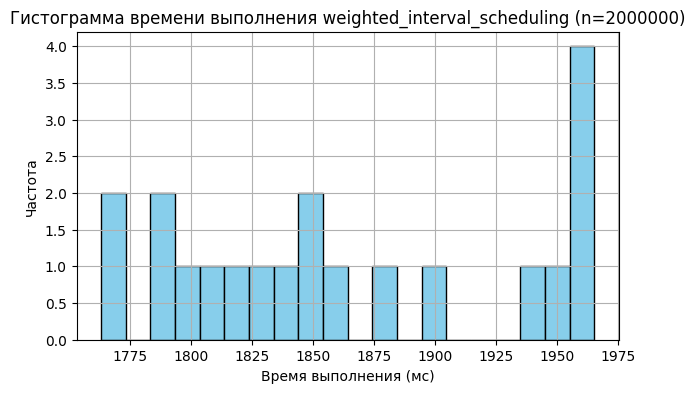

Среднее время: 1863.61 мс, Стандартное отклонение: 68.06 мс


In [63]:
times, mean_t, std_t = measure_algorithm_time(
    weighted_interval_scheduling, 
    generate_random_intervals, 
    n_hist, 
    n_trials=n_trials_hist, 
    to_ms=True
)

plt.figure(figsize=(7,4))
plt.hist(times, bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Время выполнения (мс)')
plt.ylabel('Частота')
plt.title(f'Гистограмма времени выполнения weighted_interval_scheduling (n={n_hist})')
plt.grid(True)
plt.show()

print(f"Среднее время: {mean_t:.2f} мс, Стандартное отклонение: {std_t:.2f} мс")

In [64]:
# Проверка гипотезы нормальности (Шапиро-Уилка)
stat, p_value = sts.shapiro(times)
print(f"Shapiro-Wilk test: статистика={stat:.4f}, p-value={p_value:.4f}")
if p_value > 0.05:
    print("Гипотеза о нормальном распределении не отвергается (данные примерно нормальны)")
else:
    print("Гипотеза о нормальном распределении отвергается (данные не нормальны)")

Shapiro-Wilk test: статистика=0.9107, p-value=0.0658
Гипотеза о нормальном распределении не отвергается (данные примерно нормальны)


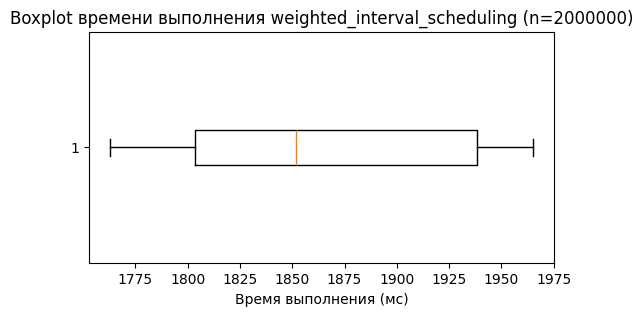

In [65]:
plt.figure(figsize=(6,3))
plt.boxplot(times, vert=False)
plt.xlabel('Время выполнения (мс)')
plt.title(f'Boxplot времени выполнения weighted_interval_scheduling (n={n_hist})')
plt.show()

In [66]:
median_t = np.median(times)
q25, q75 = np.percentile(times, [25, 75])
print(f"Медиана времени: {median_t:.2f} мс")
print(f"25% и 75% квантиль: {q25:.2f} мс, {q75:.2f} мс")
print(f"Минимум и максимум: {times.min():.2f} мс, {times.max():.2f} мс")

Медиана времени: 1851.62 мс
25% и 75% квантиль: 1803.31 мс, 1938.26 мс
Минимум и максимум: 1763.07 мс, 1965.13 мс
